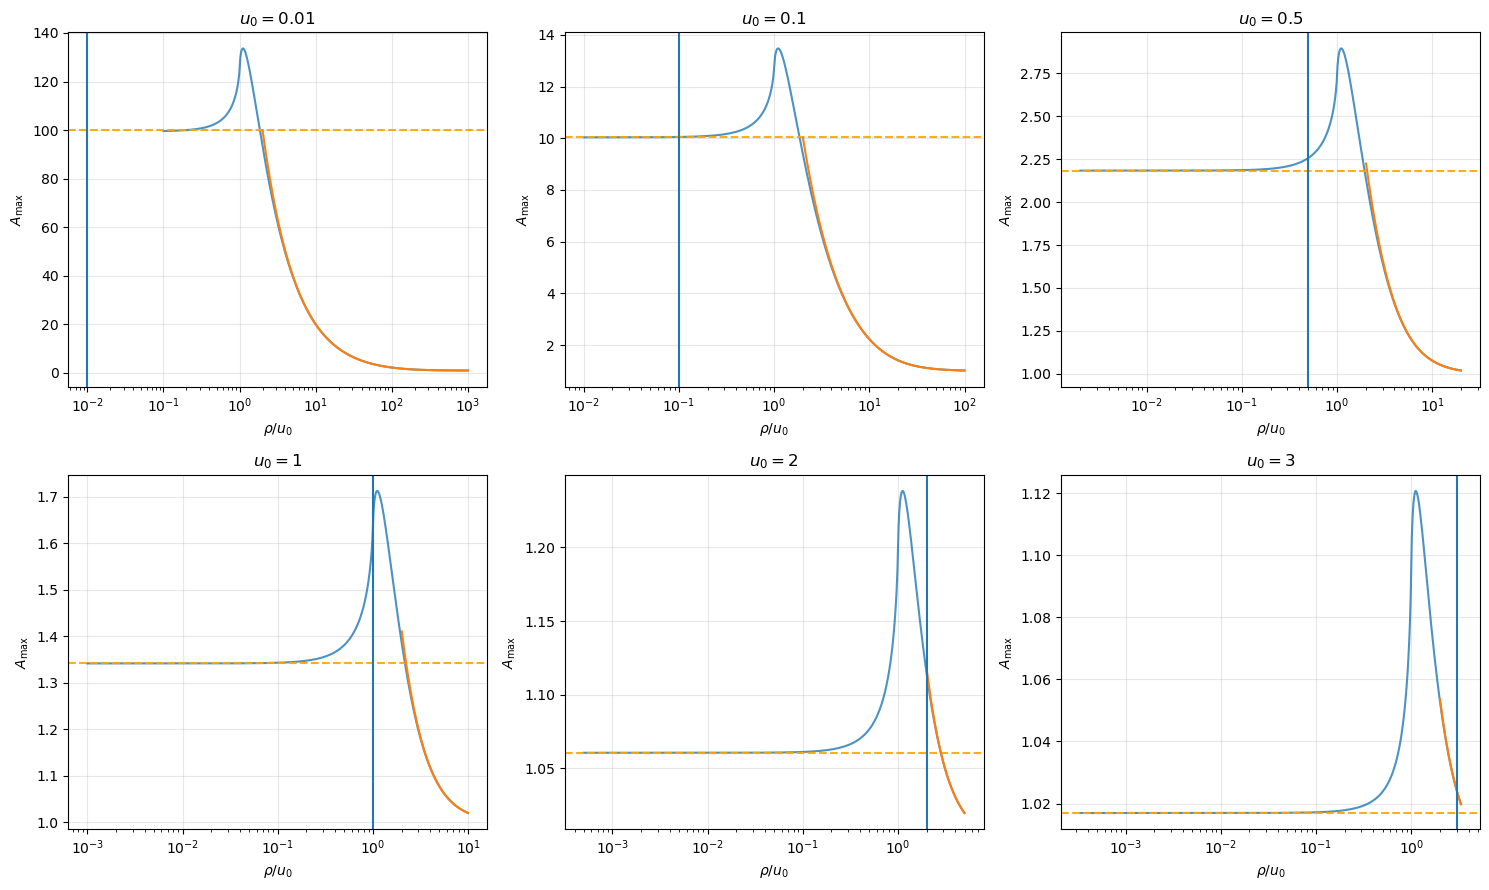

In [4]:
import numpy as np
import matplotlib.pyplot as plt

from pyLIMA import event, telescopes
from pyLIMA.models import FSPLarge_model
def A_pspl(u0):
    return (u0**2+2)/(u0*np.sqrt(u0**2+4))
# ============================================================
# Evento simulado
# ============================================================
simulated_event = event.Event()
simulated_event.name = 'Simulated'
simulated_event.ra = 170
simulated_event.dec = -70

t = np.linspace(-150, 150, 5000)

lightcurve_sim = np.c_[
    t,
    np.full_like(t, 19.0),
    np.full_like(t, 1e-9)
]

tel = telescopes.Telescope(
    name='Simulation',
    camera_filter='G',
    lightcurve=lightcurve_sim.astype(float),
    lightcurve_names=['time', 'mag', 'err_mag'],
    lightcurve_units=['JD', 'mag', 'mag'],
    location='Earth'
)

simulated_event.telescopes.append(tel)

# ============================================================
# Modelo FSPL
# ============================================================
model = FSPLarge_model.FSPLargemodel(
    simulated_event,
    parallax=['None', 0]
)

model.define_model_parameters()

# ============================================================
# Parámetros
# ============================================================
rhos = np.logspace(-3,1, 1000)

u0_list = [0.01, 0.1, 0.5, 1, 2, 3]

t0 = 0
tE = 30

# ============================================================
# Figura con subplots
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

axes = axes.flatten()

# ============================================================
# Loop sobre u0
# ============================================================
for j, u0 in enumerate(u0_list):

    ax = axes[j]

    A_max = []

    for rho in rhos:

        params_list = [t0, u0, tE, rho]

        pyLIMA_parameters = model.compute_pyLIMA_parameters(
            params_list
        )

        tel = model.event.telescopes[0]

        A = model.model_magnification(
            tel,
            pyLIMA_parameters
        )

        A_max.append(np.max(A))

    # ========================================================
    # Plot
    # ========================================================
    ax.plot(rhos/u0, np.array(A_max), alpha=0.8)
    ax.axhline(A_pspl(u0),color="orange",linestyle="dashed",alpha=0.9)
    rhos_aprox = rhos[rhos>2*u0]
    ax.plot(rhos_aprox/u0, np.sqrt(rhos_aprox**2+4)/rhos_aprox)
    ax.set_xscale("log")
    # ax.set_yscale("log")

    ax.set_title(rf"$u_0 = {u0}$")
    ax.axvline(u0)
    ax.set_xlabel(r"$\rho/u_0$")
    ax.set_ylabel(r"$A_{\max}$")

    ax.grid(alpha=0.3)

# ============================================================
# Layout
# ============================================================
plt.tight_layout()

plt.show()

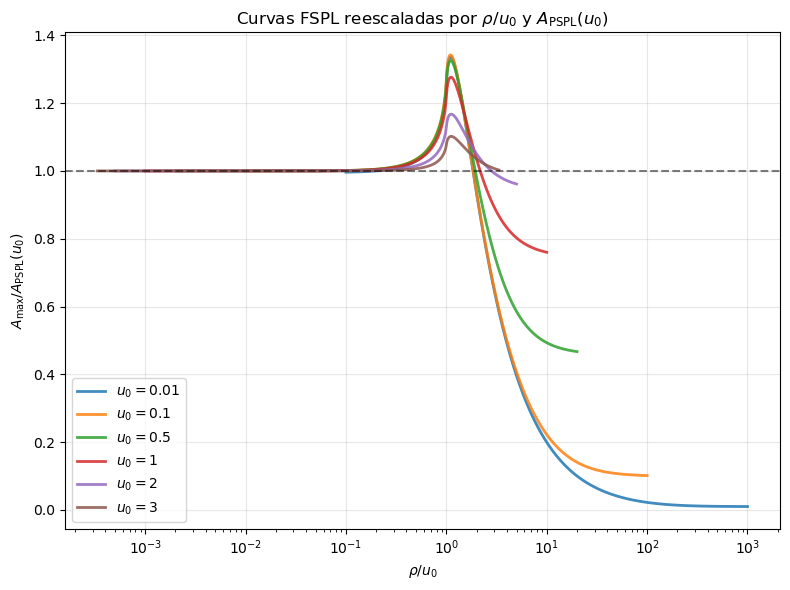

In [9]:
import numpy as np
import matplotlib.pyplot as plt

from pyLIMA import event, telescopes
from pyLIMA.models import FSPLarge_model


def A_pspl(u0):
    return (u0**2 + 2) / (u0 * np.sqrt(u0**2 + 4))


# ============================================================
# Evento simulado
# ============================================================
simulated_event = event.Event()
simulated_event.name = 'Simulated'
simulated_event.ra = 170
simulated_event.dec = -70

t = np.linspace(-150, 150, 5000)

lightcurve_sim = np.c_[
    t,
    np.full_like(t, 19.0),
    np.full_like(t, 1e-9)
]

tel = telescopes.Telescope(
    name='Simulation',
    camera_filter='G',
    lightcurve=lightcurve_sim.astype(float),
    lightcurve_names=['time', 'mag', 'err_mag'],
    lightcurve_units=['JD', 'mag', 'mag'],
    location='Earth'
)

simulated_event.telescopes.append(tel)


# ============================================================
# Modelo FSPL
# ============================================================
model = FSPLarge_model.FSPLargemodel(
    simulated_event,
    parallax=['None', 0]
)

model.define_model_parameters()


# ============================================================
# Parámetros
# ============================================================
rhos = np.logspace(-3, 1, 1000)

u0_list = [0.01, 0.1, 0.5, 1, 2, 3]

t0 = 0
tE = 30


# ============================================================
# Calcular curvas
# ============================================================
curves = {}

for u0 in u0_list:

    A_max = []

    for rho in rhos:

        params_list = [t0, u0, tE, rho]

        pyLIMA_parameters = model.compute_pyLIMA_parameters(
            params_list
        )

        tel = model.event.telescopes[0]

        A = model.model_magnification(
            tel,
            pyLIMA_parameters
        )

        A_max.append(np.max(A))

    A_max = np.array(A_max)

    curves[u0] = {
        "rho": rhos,
        "rho_over_u0": rhos / u0,
        "A_max": A_max,
        "A_scaled": A_max / A_pspl(u0),
        "A_scaled_high_mag": u0 * A_max,
    }


# ============================================================
# Figura: curvas reescaladas
# ============================================================
plt.figure(figsize=(8, 6))

for u0 in u0_list:

    x = curves[u0]["rho_over_u0"]
    y = curves[u0]["A_scaled"]

    plt.plot(
        x,
        y,
        lw=2,
        alpha=0.85,
        label=rf"$u_0={u0}$"
    )

plt.axhline(1, color="k", ls="--", alpha=0.5)

plt.xscale("log")

plt.xlabel(r"$\rho/u_0$")
plt.ylabel(r"$A_{\max}/A_{\rm PSPL}(u_0)$")

plt.title(r"Curvas FSPL reescaladas por $\rho/u_0$ y $A_{\rm PSPL}(u_0)$")

plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from pyLIMA import event, telescopes
from pyLIMA.models import FSPLarge_model


def A_pspl(u0):
    return (u0**2 + 2) / (u0 * np.sqrt(u0**2 + 4))


# ============================================================
# Evento simulado
# ============================================================
simulated_event = event.Event()
simulated_event.name = 'Simulated'
simulated_event.ra = 170
simulated_event.dec = -70

t = np.linspace(-150, 150, 5000)

lightcurve_sim = np.c_[
    t,
    np.full_like(t, 19.0),
    np.full_like(t, 1e-9)
]

tel = telescopes.Telescope(
    name='Simulation',
    camera_filter='G',
    lightcurve=lightcurve_sim.astype(float),
    lightcurve_names=['time', 'mag', 'err_mag'],
    lightcurve_units=['JD', 'mag', 'mag'],
    location='Earth'
)

simulated_event.telescopes.append(tel)


# ============================================================
# Modelo FSPL
# ============================================================
model = FSPLarge_model.FSPLargemodel(
    simulated_event,
    parallax=['None', 0]
)

model.define_model_parameters()


# ============================================================
# Parámetros
# ============================================================
rhos = np.logspace(-3, 1, 1000)

u0_list = [0.01, 0.1, 0.5, 1, 2, 3]

t0 = 0
tE = 30


# ============================================================
# Calcular curvas
# ============================================================
curves = {}

for u0 in u0_list:

    A_max = []

    for rho in rhos:

        params_list = [t0, u0, tE, rho]

        pyLIMA_parameters = model.compute_pyLIMA_parameters(
            params_list
        )

        tel = model.event.telescopes[0]

        A = model.model_magnification(
            tel,
            pyLIMA_parameters
        )

        A_max.append(np.max(A))

    A_max = np.array(A_max)

    curves[u0] = {
        "rho": rhos,
        "rho_over_u0": rhos / u0,
        "A_max": A_max,
        "A_scaled": A_max / A_pspl(u0),
        "A_scaled_high_mag": u0 * A_max,
    }


# ============================================================
# Figura: curvas reescaladas
# ============================================================
plt.figure(figsize=(8, 6))

for u0 in u0_list:

    x = curves[u0]["rho_over_u0"]
    y = curves[u0]["A_scaled"]

    plt.plot(
        x,
        y,
        lw=2,
        alpha=0.85,
        label=rf"$u_0={u0}$"
    )

plt.axhline(1, color="k", ls="--", alpha=0.5)

plt.xscale("log")

plt.xlabel(r"$\rho/u_0$")
plt.ylabel(r"$A_{\max}/A_{\rm PSPL}(u_0)$")

plt.title(r"Curvas FSPL reescaladas por $\rho/u_0$ y $A_{\rm PSPL}(u_0)$")

plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

In [14]:
import numpy as np

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

from astropy.time import Time

from pyLIMA import event, telescopes
from pyLIMA.models import FSPLarge_model


def A_pspl(u0):
    return (u0**2 + 2.0) / (u0 * np.sqrt(u0**2 + 4.0))


# ============================================================
# Parámetros fijos
# ============================================================
t0_date = "2026-06-09T00:00:00"
t0 = float(Time(t0_date, scale="utc").jd)

u0 = 0.1
tE = 30.0

rho_max = 100.0

theta_piE = np.pi / 4.0

piE_values = np.logspace(-3, 1, 100)

# ============================================================
# Casos de rho/u0
# Se eligen 9 valores, asegurando rho <= 100
# ============================================================
rho_over_u0_min = 1e-3
rho_over_u0_max = rho_max / u0

rho_over_u0_list = np.logspace(
    np.log10(rho_over_u0_min),
    np.log10(rho_over_u0_max),
    9
)

rho_list = u0 * rho_over_u0_list

print(f"t0 JD = {t0}")
print(f"u0 = {u0}")
print(f"tE = {tE}")
print("rho/u0 values:")
print(rho_over_u0_list)
print("rho values:")
print(rho_list)


# ============================================================
# Evento simulado
# ============================================================
simulated_event = event.Event()
simulated_event.name = "Simulated"
simulated_event.ra = 170.0
simulated_event.dec = -70.0

t = np.linspace(t0 - 150.0, t0 + 150.0, 5000)

lightcurve_sim = np.c_[
    t,
    np.full_like(t, 19.0),
    np.full_like(t, 1e-9)
]

tel = telescopes.Telescope(
    name="Simulation",
    camera_filter="G",
    lightcurve=lightcurve_sim.astype(float),
    lightcurve_names=["time", "mag", "err_mag"],
    lightcurve_units=["JD", "mag", "mag"],
    location="Earth"
)

simulated_event.telescopes.append(tel)


# ============================================================
# Modelo FSPL con paralaje
# ============================================================
model = FSPLarge_model.FSPLargemodel(
    simulated_event,
    parallax=["Full", t0]
)

model.define_model_parameters()

tel = model.event.telescopes[0]


# ============================================================
# Figura 3x3
# ============================================================
fig, axes = plt.subplots(
    3,
    3,
    figsize=(13, 10),
    sharex=True,
    sharey=True
)

axes = axes.flatten()

for ax, rho_over_u0, rho in zip(axes, rho_over_u0_list, rho_list):

    if rho > rho_max:
        raise ValueError(
            f"rho = {rho} is larger than rho_max = {rho_max}"
        )

    Amax_scaled_values = []

    for piE in piE_values:

        piEN = piE * np.sin(theta_piE)
        piEE = piE * np.cos(theta_piE)

        params_list = [
            float(t0),
            float(u0),
            float(tE),
            float(rho),
            float(piEN),
            float(piEE),
        ]

        pyLIMA_parameters = model.compute_pyLIMA_parameters(
            params_list
        )

        A = model.model_magnification(
            tel,
            pyLIMA_parameters
        )

        Amax = np.nanmax(A)

        Amax_scaled_values.append(
            Amax / A_pspl(u0)
        )

    Amax_scaled_values = np.array(Amax_scaled_values)

    ax.plot(
        piE_values,
        Amax_scaled_values,
        lw=2
    )

    ax.axhline(
        1.0,
        color="k",
        linestyle="--",
        alpha=0.5
    )

    ax.set_xscale("log")

    ax.set_title(
        rf"$\rho/u_0={rho_over_u0:.2g}$, $\rho={rho:.2g}$"
    )

    ax.grid(alpha=0.3)


# ============================================================
# Labels
# ============================================================
for ax in axes[6:]:
    ax.set_xlabel(r"$\pi_E$")

for ax in axes[::3]:
    ax.set_ylabel(r"$A_{\max}/A_{\rm PSPL}(u_0)$")


fig.suptitle(
    rf"Fixed $u_0={u0}$, $t_E={tE}$ d, $t_0={t0_date}$",
    fontsize=14
)

plt.tight_layout()

output = "sweep_piE_grid_rho_over_u0.png"
plt.savefig(output, dpi=250)

print(f"Saved figure to {output}")

t0 JD = 2461200.5
u0 = 0.1
tE = 30.0
rho/u0 values:
[1.00000000e-03 5.62341325e-03 3.16227766e-02 1.77827941e-01
 1.00000000e+00 5.62341325e+00 3.16227766e+01 1.77827941e+02
 1.00000000e+03]
rho values:
[1.00000000e-04 5.62341325e-04 3.16227766e-03 1.77827941e-02
 1.00000000e-01 5.62341325e-01 3.16227766e+00 1.77827941e+01
 1.00000000e+02]
Parallax(Full) estimated for the telescope Simulation: SUCCESS
Saved figure to sweep_piE_grid_rho_over_u0.png
